# DuPont Analysis: What Drives ROE in Big Tech?
### ACC102 Mini Assignment — Track 4: Interactive Data Analysis Tool

---

## Section 1 — Problem Definition

**Analytical Question:**  
Return on Equity (ROE) is one of the most widely used profitability metrics in finance. But a high ROE can come from very different sources — strong profit margins, efficient asset use, or heavy financial leverage. The DuPont decomposition breaks ROE into its component drivers, revealing *why* a company earns what it earns.

**This notebook asks:**  
> Among Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA), what drives ROE differences — and how have those drivers changed over time?

**Target Audience:**  
Undergraduate finance/accounting students, retail investors, and equity analysts who want to move beyond headline ROE figures.

**Five-Factor DuPont Formula:**

$$ROE = \underbrace{\frac{\text{Net Income}}{\text{EBT}}}_{\text{Tax Burden}} \times \underbrace{\frac{\text{EBT}}{\text{EBIT}}}_{\text{Interest Burden}} \times \underbrace{\frac{\text{EBIT}}{\text{Revenue}}}_{\text{EBIT Margin}} \times \underbrace{\frac{\text{Revenue}}{\text{Assets}}}_{\text{Asset Turnover}} \times \underbrace{\frac{\text{Assets}}{\text{Equity}}}_{\text{Equity Multiplier}}$$

**Data Source:**  
Yahoo Finance via `yfinance` Python library. Fiscal year financial statements and year-end stock prices for AAPL, MSFT, TSLA. Accessed: April 2026.


## Section 2 — Imports & Data Loading

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {'AAPL': '#555555', 'MSFT': '#00A4EF', 'TSLA': '#E31937'}
TICKERS = ['AAPL', 'MSFT', 'TSLA']


In [28]:
# Load CSV files — adjust path if needed
inc = pd.read_csv('data/income_statement.csv', index_col='fiscal_year', parse_dates=True)
bal = pd.read_csv('data/balance_sheet.csv',    index_col='fiscal_year', parse_dates=True)
price = pd.read_csv('data/stock_price_annual.csv', index_col='date',   parse_dates=True)

print("Income Statement shape :", inc.shape)
print("Balance Sheet shape    :", bal.shape)
print("Stock Price shape      :", price.shape)
print()
print("Years available per ticker (Income):")
print(inc.groupby('ticker').apply(lambda x: sorted(x.index.year.tolist())))


Income Statement shape : (14, 53)
Balance Sheet shape    : (15, 98)
Stock Price shape      : (33, 2)

Years available per ticker (Income):
ticker
AAPL    [2021, 2022, 2023, 2024, 2025]
MSFT          [2022, 2023, 2024, 2025]
TSLA    [2021, 2022, 2023, 2024, 2025]
dtype: object


In [29]:
# Quick preview of key fields
key_inc = ['Total Revenue', 'EBIT', 'Pretax Income', 'Net Income', 'Tax Provision', 'ticker']
key_bal = ['Total Assets', 'Common Stock Equity', 'ticker']

print("=== Income Statement (key fields) ===")
display(inc[key_inc].head(6))

print("\n=== Balance Sheet (key fields) ===")
display(bal[key_bal].head(6))


=== Income Statement (key fields) ===


,Total Revenue,EBIT,Pretax Income,Net Income,Tax Provision,ticker
fiscal_year,,,,,,
2025-09-30,4.161610e+11,1.330500e+11,1.327290e+11,1.120100e+11,2.071900e+10,AAPL
2024-09-30,3.910350e+11,1.232160e+11,1.234850e+11,9.373600e+10,2.974900e+10,AAPL
2023-09-30,3.832850e+11,1.143010e+11,1.137360e+11,9.699500e+10,1.674100e+10,AAPL
2022-09-30,3.943280e+11,1.194370e+11,1.191030e+11,9.980300e+10,1.930000e+10,AAPL
2021-09-30,NaN,NaN,NaN,NaN,NaN,AAPL
2025-06-30,2.817240e+11,1.260120e+11,1.236270e+11,1.018320e+11,2.179500e+10,MSFT



=== Balance Sheet (key fields) ===


,Total Assets,Common Stock Equity,ticker
fiscal_year,,,
2025-09-30,3.592410e+11,7.373300e+10,AAPL
2024-09-30,3.649800e+11,5.695000e+10,AAPL
2023-09-30,3.525830e+11,6.214600e+10,AAPL
2022-09-30,3.527550e+11,5.067200e+10,AAPL
2021-09-30,NaN,NaN,AAPL
2025-06-30,6.190030e+11,3.434790e+11,MSFT


## Section 3 — Data Cleaning & Preparation

We extract only the columns needed for the five-factor DuPont model and rename them for clarity.  
Missing values are noted and rows with insufficient data are dropped.


In [30]:
# Extract and rename fields
inc_clean = inc[['Total Revenue', 'EBIT', 'Pretax Income', 'Net Income', 'ticker']].copy()
inc_clean.columns = ['Revenue', 'EBIT', 'EBT', 'NetIncome', 'ticker']

bal_clean = bal[['Total Assets', 'Common Stock Equity', 'ticker']].copy()
bal_clean.columns = ['TotalAssets', 'Equity', 'ticker']

# Add year column for merging
inc_clean['year'] = inc_clean.index.year
bal_clean['year'] = bal_clean.index.year

# Merge on ticker + year
df = pd.merge(
    inc_clean.reset_index(drop=True),
    bal_clean.reset_index(drop=True),
    on=['ticker', 'year']
)

# Drop rows missing any key field
df.dropna(subset=['Revenue', 'EBIT', 'EBT', 'NetIncome', 'TotalAssets', 'Equity'], inplace=True)
df.sort_values(['ticker', 'year'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Clean dataset: {len(df)} rows")
display(df.head(8))


Clean dataset: 12 rows


,Revenue,EBIT,EBT,NetIncome,ticker,year,TotalAssets,Equity
0,3.943280e+11,1.194370e+11,1.191030e+11,9.980300e+10,AAPL,2022,3.527550e+11,5.067200e+10
1,3.832850e+11,1.143010e+11,1.137360e+11,9.699500e+10,AAPL,2023,3.525830e+11,6.214600e+10
2,3.910350e+11,1.232160e+11,1.234850e+11,9.373600e+10,AAPL,2024,3.649800e+11,5.695000e+10
3,4.161610e+11,1.330500e+11,1.327290e+11,1.120100e+11,AAPL,2025,3.592410e+11,7.373300e+10
4,1.982700e+11,8.577900e+10,8.371600e+10,7.273800e+10,MSFT,2022,3.648400e+11,1.665420e+11
5,2.119150e+11,9.127900e+10,8.931100e+10,7.236100e+10,MSFT,2023,4.119760e+11,2.062230e+11
6,2.451220e+11,1.107220e+11,1.077870e+11,8.813600e+10,MSFT,2024,5.121630e+11,2.684770e+11
7,2.817240e+11,1.260120e+11,1.236270e+11,1.018320e+11,MSFT,2025,6.190030e+11,3.434790e+11


In [31]:
# Check for zero/negative equity (would distort ratios)
issues = df[df['Equity'] <= 0]
if len(issues) > 0:
    print("⚠️  Rows with zero/negative equity (excluded from ratio calc):")
    display(issues[['ticker','year','Equity']])
else:
    print("✅  No zero/negative equity issues found.")


✅  No zero/negative equity issues found.


## Section 4 — Five-Factor DuPont Calculation

| Factor | Formula | What it measures |
|--------|---------|-----------------|
| Tax Burden | Net Income / EBT | How much profit survives after tax |
| Interest Burden | EBT / EBIT | Impact of interest payments |
| EBIT Margin | EBIT / Revenue | Operating profitability |
| Asset Turnover | Revenue / Total Assets | Efficiency of asset use |
| Equity Multiplier | Total Assets / Equity | Financial leverage |
| **ROE** | Product of all five | **Return on Equity** |


In [32]:
# Calculate five factors
df_calc = df[df['Equity'] > 0].copy()

df_calc['TaxBurden']       = df_calc['NetIncome']   / df_calc['EBT']
df_calc['InterestBurden']  = df_calc['EBT']         / df_calc['EBIT']
df_calc['EBITMargin']      = df_calc['EBIT']         / df_calc['Revenue']
df_calc['AssetTurnover']   = df_calc['Revenue']      / df_calc['TotalAssets']
df_calc['EquityMultiplier']= df_calc['TotalAssets']  / df_calc['Equity']

# Reconstructed ROE from DuPont (should match direct ROE closely)
df_calc['ROE_dupont'] = (
    df_calc['TaxBurden'] *
    df_calc['InterestBurden'] *
    df_calc['EBITMargin'] *
    df_calc['AssetTurnover'] *
    df_calc['EquityMultiplier']
)

# Direct ROE for verification
df_calc['ROE_direct'] = df_calc['NetIncome'] / df_calc['Equity']

print("DuPont Factors Summary:")
display(df_calc[['ticker','year','TaxBurden','InterestBurden','EBITMargin',
                  'AssetTurnover','EquityMultiplier','ROE_dupont','ROE_direct']].round(3))


DuPont Factors Summary:


,ticker,year,TaxBurden,InterestBurden,EBITMargin,AssetTurnover,EquityMultiplier,ROE_dupont,ROE_direct
0,AAPL,2022,0.838,0.997,0.303,1.118,6.962,1.970,1.970
1,AAPL,2023,0.853,0.995,0.298,1.087,5.673,1.561,1.561
2,AAPL,2024,0.759,1.002,0.315,1.071,6.409,1.646,1.646
3,AAPL,2025,0.844,0.998,0.320,1.158,4.872,1.519,1.519
4,MSFT,2022,0.869,0.976,0.433,0.543,2.191,0.437,0.437
5,MSFT,2023,0.810,0.978,0.431,0.514,1.998,0.351,0.351
6,MSFT,2024,0.818,0.973,0.452,0.479,1.908,0.328,0.328
7,MSFT,2025,0.824,0.981,0.447,0.455,1.802,0.296,0.296
8,TSLA,2022,0.917,0.986,0.171,0.989,1.842,0.281,0.281
9,TSLA,2023,1.504,0.985,0.105,0.908,1.702,0.239,0.239


In [33]:
# Verify DuPont reconstruction accuracy
df_calc['recon_error'] = abs(df_calc['ROE_dupont'] - df_calc['ROE_direct'])
print("Max reconstruction error:", round(df_calc['recon_error'].max(), 6))
print("Mean reconstruction error:", round(df_calc['recon_error'].mean(), 6))
print("\n✅ DuPont reconstruction is accurate if errors are near zero.")


Max reconstruction error: 0.0
Mean reconstruction error: 0.0

✅ DuPont reconstruction is accurate if errors are near zero.


## Section 4b — Industry Benchmark & ROE Quality Scoring

Beyond calculating the five factors, we assess **ROE quality** — i.e., how sustainably the ROE is earned.

**Industry Benchmark:** Approximate 5-year average for the S&P 500 Information Technology sector.  
These figures serve as a reference to contextualise each company's factor values.

**Scoring Logic:**  
We weight each factor's deviation from the benchmark, placing the highest weight on operational drivers  
(EBIT Margin and Asset Turnover) and penalising excessive financial leverage (Equity Multiplier).  
This reflects the principle that margin- and efficiency-driven ROE is more durable than leverage-driven ROE.


In [34]:
# ── Industry Benchmarks (S&P 500 IT sector, approx. 5-yr avg) ──
INDUSTRY_BENCH = {
    'TaxBurden':        0.83,
    'InterestBurden':   0.94,
    'EBITMargin':       0.22,
    'AssetTurnover':    0.55,
    'EquityMultiplier': 2.80,
    'ROE':              0.28,
}

FACTOR_COLS   = ['TaxBurden','InterestBurden','EBITMargin','AssetTurnover','EquityMultiplier']
FACTOR_LABELS = ['Tax Burden','Interest Burden','EBIT Margin','Asset Turnover','Equity Multiplier']

print("Industry Benchmarks:")
for k, v in INDUSTRY_BENCH.items():
    print(f"  {k:<22} {v:.3f}")


Industry Benchmarks:
  TaxBurden              0.830
  InterestBurden         0.940
  EBITMargin             0.220
  AssetTurnover          0.550
  EquityMultiplier       2.800
  ROE                    0.280


In [35]:
# ── ROE Quality Scoring Function ────────────────────────
def roe_quality_score(row):
    """
    Score ROE quality 0-100 based on WHERE the ROE comes from.
    
    Weights:
      EBIT Margin      35% — core operating profitability (most sustainable)
      Asset Turnover   25% — efficiency of assets
      Tax Burden       15% — tax management
      Interest Burden  15% — debt cost management
      Leverage penalty 10% — high leverage lowers score (less sustainable)
    
    Returns: score (float), grade (str), colour (str), narrative (str)
    """
    margin_score   = min(row['EBITMargin']       / INDUSTRY_BENCH['EBITMargin'],       2.0)
    turnover_score = min(row['AssetTurnover']     / INDUSTRY_BENCH['AssetTurnover'],    2.0)
    tax_score      = min(row['TaxBurden']         / INDUSTRY_BENCH['TaxBurden'],        2.0)
    interest_score = min(row['InterestBurden']    / INDUSTRY_BENCH['InterestBurden'],   2.0)
    leverage_score = max(2.0 - row['EquityMultiplier'] / INDUSTRY_BENCH['EquityMultiplier'], 0.0)

    composite = (
        margin_score   * 0.35 +
        turnover_score * 0.25 +
        tax_score      * 0.15 +
        interest_score * 0.15 +
        leverage_score * 0.10
    ) * 50  # scale to 100
    composite = min(max(composite, 0), 100)

    # Identify dominant driver
    if row['EBITMargin'] > INDUSTRY_BENCH['EBITMargin'] * 1.3:
        driver = "strong operating margins"
    elif row['AssetTurnover'] > INDUSTRY_BENCH['AssetTurnover'] * 1.3:
        driver = "high asset efficiency"
    elif row['EquityMultiplier'] > INDUSTRY_BENCH['EquityMultiplier'] * 1.5:
        driver = "financial leverage (buybacks/debt)"
    else:
        driver = "balanced operational performance"

    if composite >= 70:
        grade, colour = "A — High Quality",     "#27AE60"
        note = f"ROE is driven by {driver} — genuinely earned and likely sustainable."
    elif composite >= 45:
        grade, colour = "B — Moderate Quality", "#F39C12"
        note = f"ROE is partially driven by {driver} — monitor leverage trends."
    else:
        grade, colour = "C — Low Quality",      "#E74C3C"
        note = f"ROE is largely driven by {driver} — headline figure may be misleading."

    return round(composite, 1), grade, colour, note


# Apply to latest year for each company
latest_score = df_calc.sort_values('year').groupby('ticker').last().reset_index()

print(f"{'Ticker':<8} {'Year':<6} {'ROE':>8} {'Score':>7}  Grade")
print("-" * 55)
for _, row in latest_score.iterrows():
    score, grade, _, note = roe_quality_score(row)
    print(f"{row['ticker']:<8} {int(row['year']):<6} {row['ROE_direct']:>8.1%} {score:>7.1f}  {grade}")
    print(f"         → {note}")
    print()


Ticker   Year        ROE   Score  Grade
-------------------------------------------------------
AAPL     2025     151.9%    67.3  B — Moderate Quality
         → ROE is partially driven by strong operating margins — monitor leverage trends.

MSFT     2025      29.6%    67.4  B — Moderate Quality
         → ROE is partially driven by strong operating margins — monitor leverage trends.

TSLA     2025       4.6%    41.3  C — Low Quality
         → ROE is largely driven by balanced operational performance — headline figure may be misleading.



## Section 5 — Visualisation

We produce four charts:
1. **ROE Trend** — headline ROE over time for all three companies
2. **Factor Contribution** — stacked bar showing what drives ROE each year (per company)
3. **Radar Chart** — latest-year snapshot comparison across all five factors
4. **ROE vs Stock Price** — does market price follow fundamental ROE?


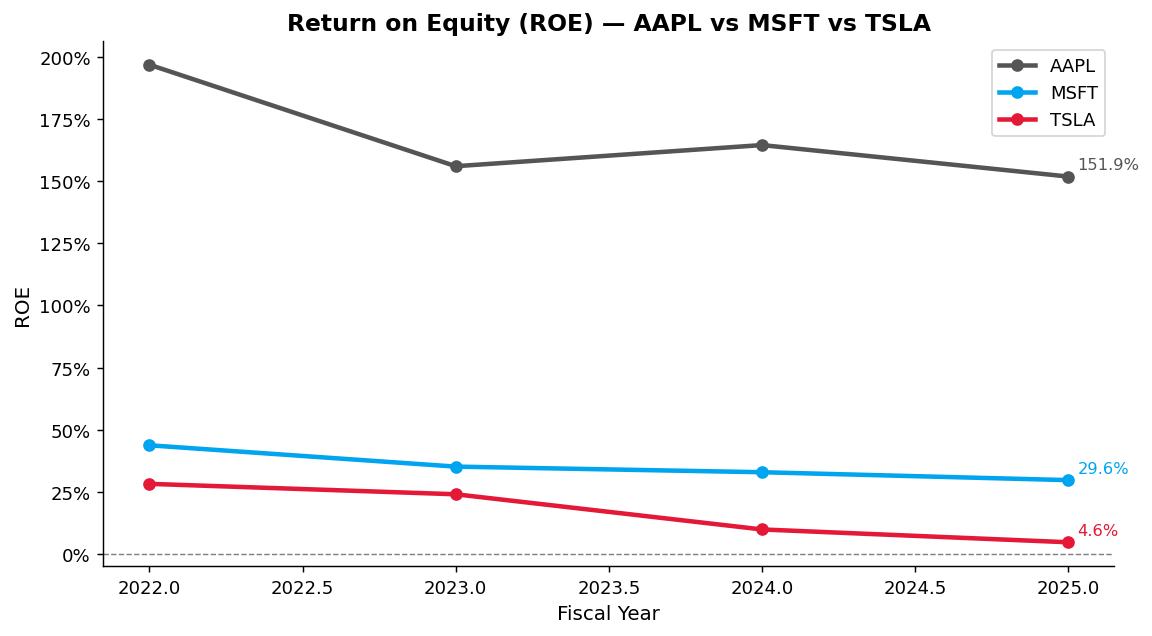

Saved: chart1_roe_trend.png


In [36]:
# ── Chart 1: ROE Trend ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for ticker in TICKERS:
    d = df_calc[df_calc['ticker'] == ticker].sort_values('year')
    ax.plot(d['year'], d['ROE_direct'], marker='o', linewidth=2.5,
            color=COLORS[ticker], label=ticker)
    # Annotate last point
    last = d.iloc[-1]
    ax.annotate(f"{last['ROE_direct']:.1%}",
                xy=(last['year'], last['ROE_direct']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=9, color=COLORS[ticker])

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Return on Equity (ROE) — AAPL vs MSFT vs TSLA", fontweight='bold')
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("ROE")
ax.legend()
plt.tight_layout()
plt.savefig('chart1_roe_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_roe_trend.png")


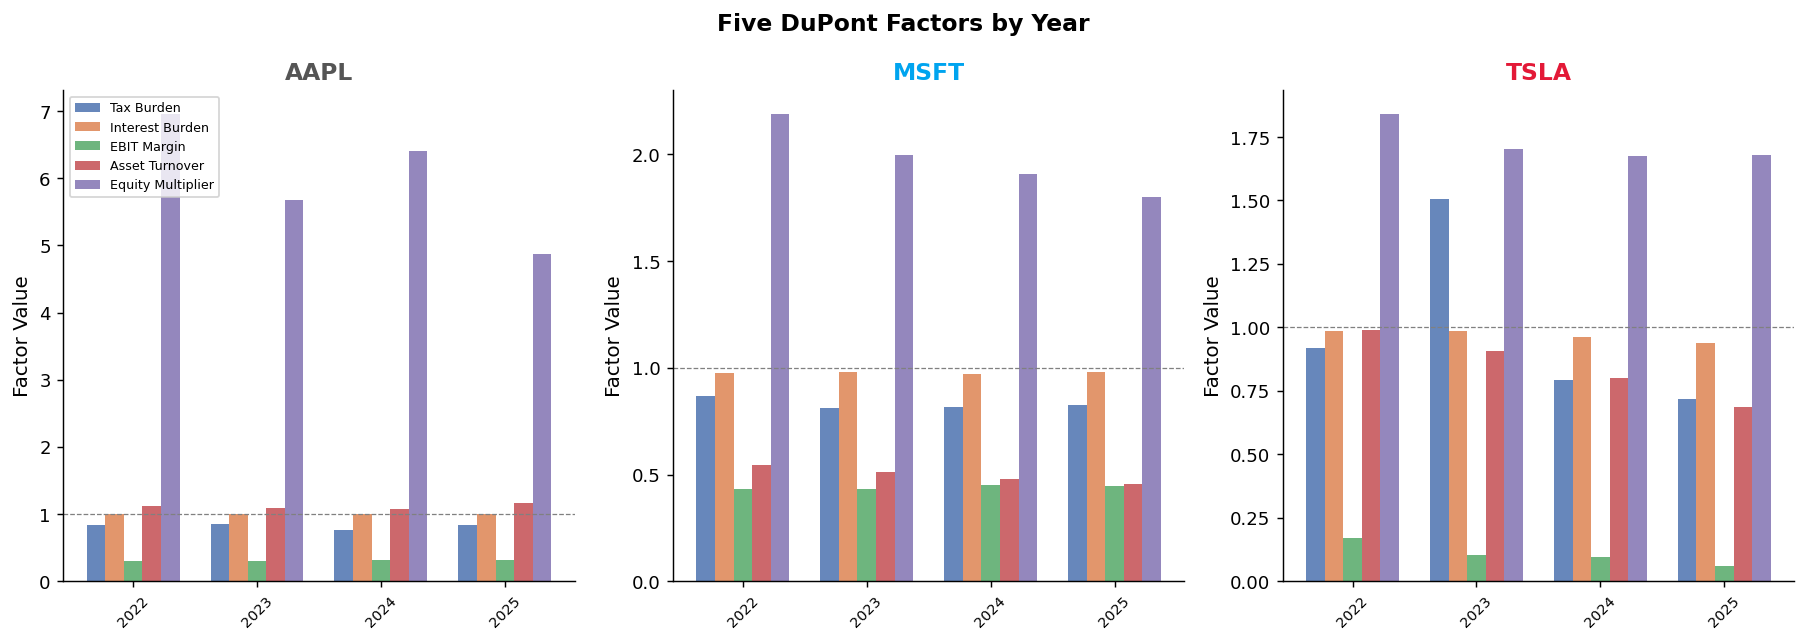

Saved: chart2_factors.png


In [37]:
# ── Chart 2: Factor Contribution (log-scale stacked bar) ──
# We show the five factors' absolute values side by side per year per company
factors = ['TaxBurden', 'InterestBurden', 'EBITMargin', 'AssetTurnover', 'EquityMultiplier']
factor_labels = ['Tax Burden', 'Interest Burden', 'EBIT Margin', 'Asset Turnover', 'Equity Multiplier']
factor_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    d = df_calc[df_calc['ticker'] == ticker].sort_values('year')
    years = d['year'].tolist()
    x = np.arange(len(years))
    width = 0.15
    for i, (factor, label, color) in enumerate(zip(factors, factor_labels, factor_colors)):
        ax.bar(x + i * width, d[factor], width, label=label, color=color, alpha=0.85)
    ax.set_title(ticker, fontweight='bold', color=COLORS[ticker])
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.set_ylabel("Factor Value")
    ax.axhline(1, color='gray', linewidth=0.7, linestyle='--')

axes[0].legend(loc='upper left', fontsize=7)
fig.suptitle("Five DuPont Factors by Year", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('chart2_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_factors.png")


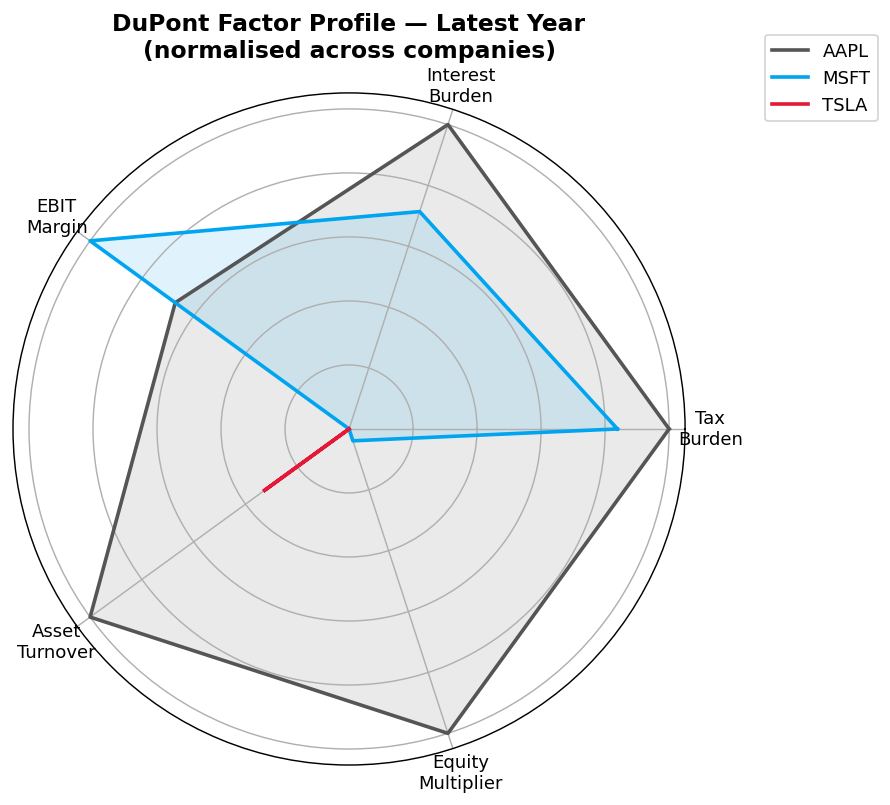

Saved: chart3_radar.png


In [38]:
# ── Chart 3: Radar Chart (latest year comparison) ──────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Use most recent year available for each ticker
latest = df_calc.sort_values('year').groupby('ticker').last().reset_index()

# Normalise each factor to 0-1 range across the three companies for radar
radar_factors = ['TaxBurden', 'InterestBurden', 'EBITMargin', 'AssetTurnover', 'EquityMultiplier']
radar_labels  = ['Tax\nBurden', 'Interest\nBurden', 'EBIT\nMargin', 'Asset\nTurnover', 'Equity\nMultiplier']

# Min-max normalise
norm = latest[radar_factors].copy()
for col in radar_factors:
    mn, mx = norm[col].min(), norm[col].max()
    norm[col] = (norm[col] - mn) / (mx - mn + 1e-9)

N = len(radar_factors)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for idx, row in norm.iterrows():
    ticker = latest.loc[idx, 'ticker']
    values = row[radar_factors].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, color=COLORS[ticker], label=ticker)
    ax.fill(angles, values, alpha=0.12, color=COLORS[ticker])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_yticklabels([])
ax.set_title("DuPont Factor Profile — Latest Year\n(normalised across companies)",
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('chart3_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_radar.png")


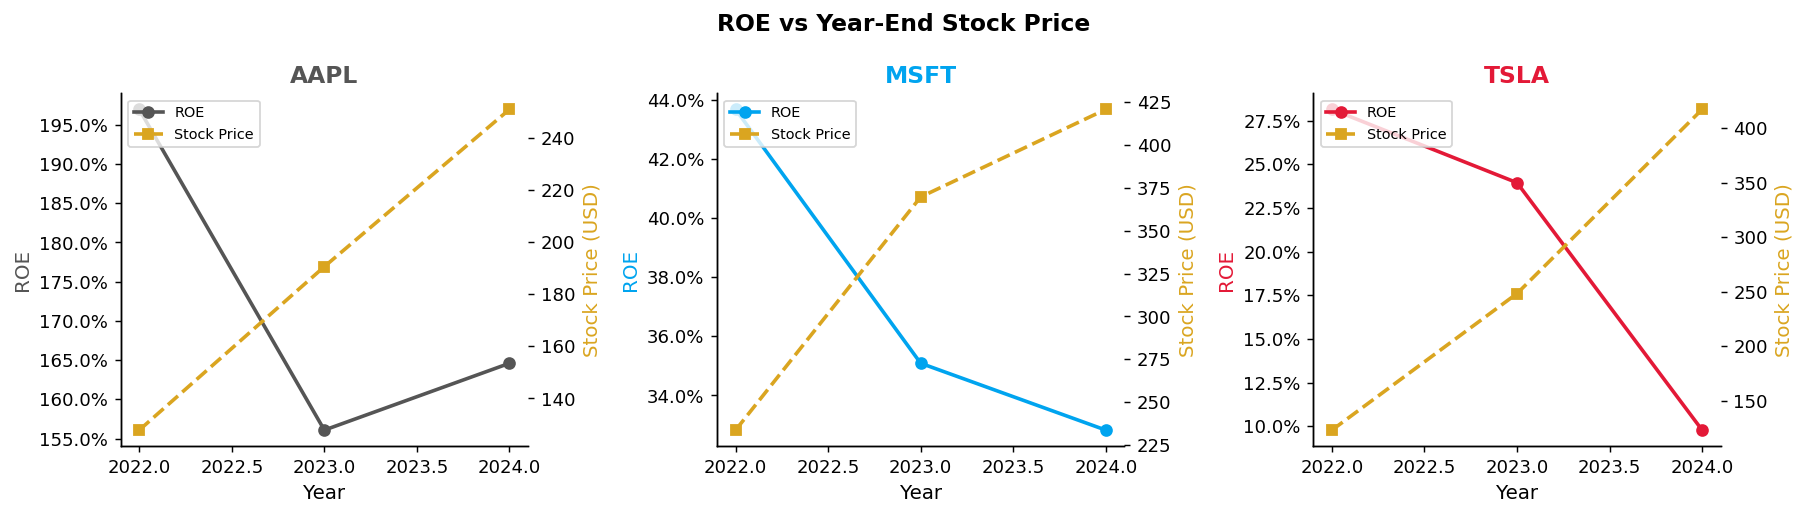

Saved: chart4_roe_vs_price.png


In [39]:
# ── Chart 4: ROE vs Stock Price ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, ticker in zip(axes, TICKERS):
    d = df_calc[df_calc['ticker'] == ticker].sort_values('year').copy()
    p = price[price['ticker'] == ticker].copy()
    p['year'] = p.index.year

    merged = pd.merge(d[['year','ROE_direct']], p[['year','close_year_end']], on='year')
    if merged.empty:
        ax.set_title(f"{ticker} — no overlap")
        continue

    ax2 = ax.twinx()
    ax.plot(merged['year'], merged['ROE_direct'], color=COLORS[ticker],
            marker='o', linewidth=2, label='ROE')
    ax2.plot(merged['year'], merged['close_year_end'], color='goldenrod',
             marker='s', linewidth=2, linestyle='--', label='Stock Price')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(ticker, fontweight='bold', color=COLORS[ticker])
    ax.set_xlabel("Year")
    ax.set_ylabel("ROE", color=COLORS[ticker])
    ax2.set_ylabel("Stock Price (USD)", color='goldenrod')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

fig.suptitle("ROE vs Year-End Stock Price", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('chart4_roe_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_roe_vs_price.png")


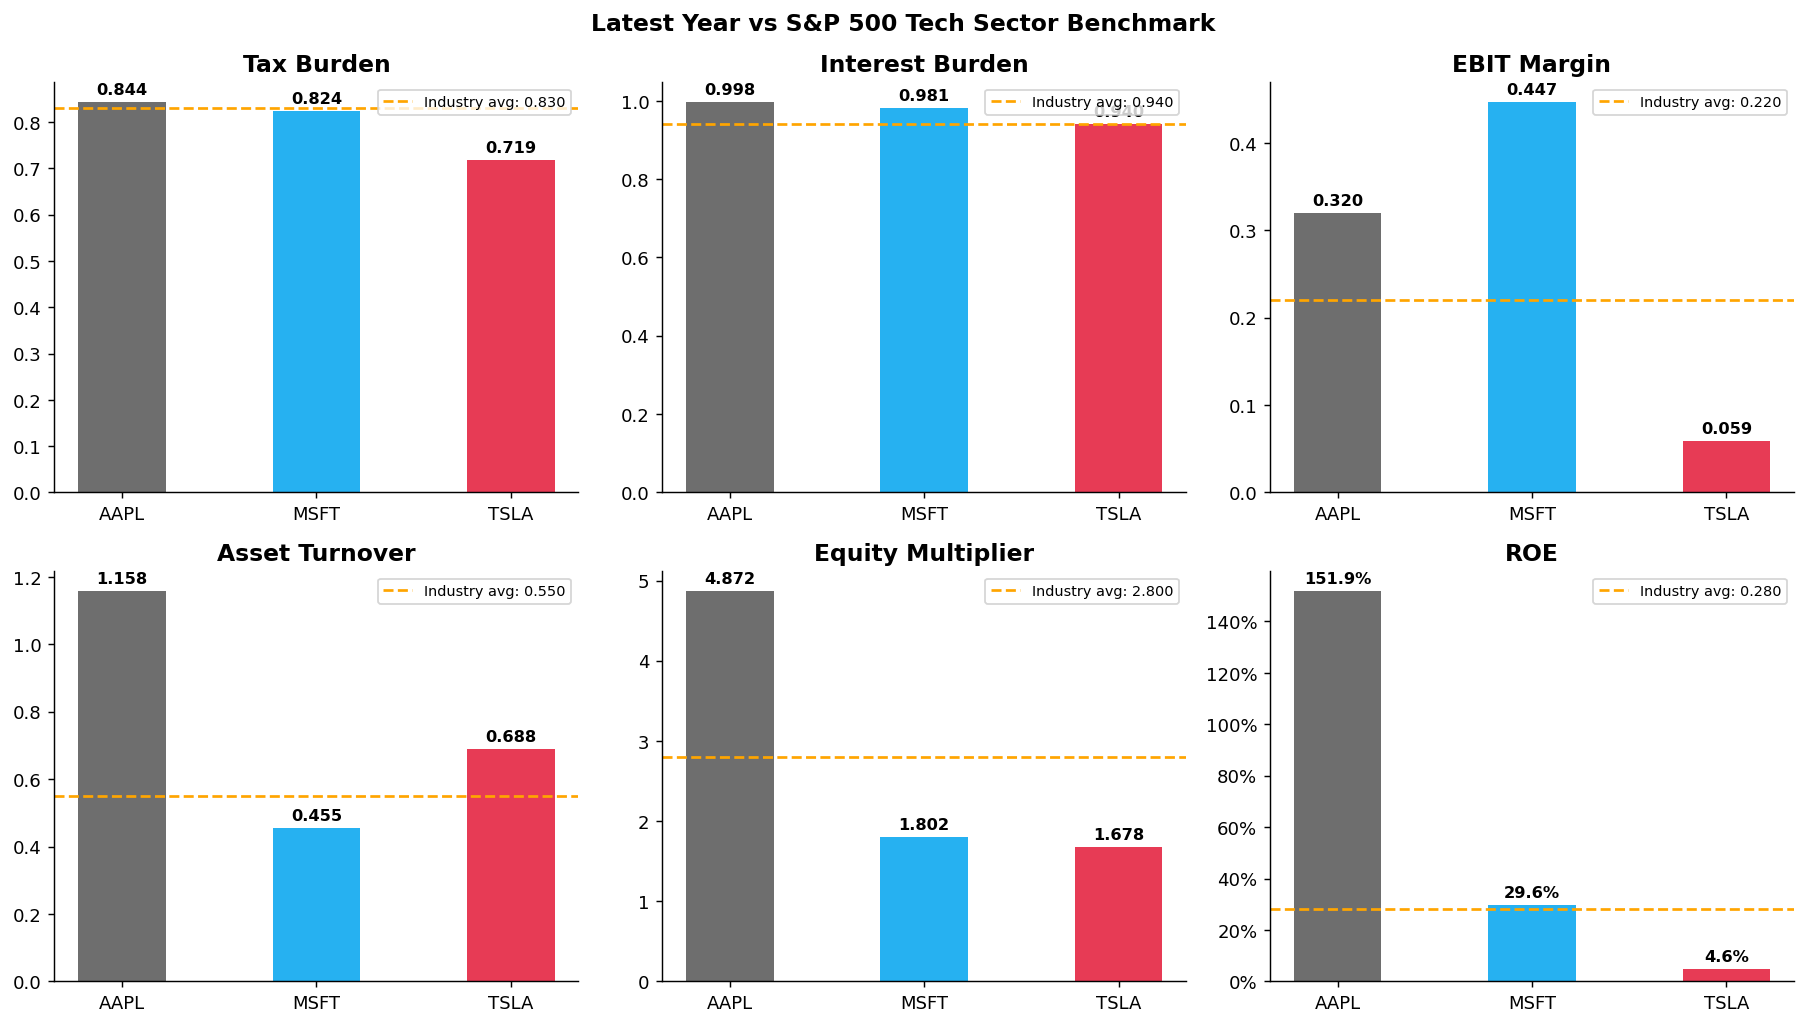

Saved: chart5_benchmark.png


In [40]:
# ── Chart 5: Industry Benchmark Comparison ─────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_items = FACTOR_COLS + ['ROE_direct']
plot_names = FACTOR_LABELS + ['ROE']
bench_keys = FACTOR_COLS + ['ROE']

latest_b = df_calc.sort_values('year').groupby('ticker').last().reset_index()

for ax, fcol, fname, bkey in zip(axes.flat, plot_items, plot_names, bench_keys):
    vals   = [float(latest_b.loc[latest_b['ticker']==t, fcol].values[0])
              if t in latest_b['ticker'].values else 0 for t in TICKERS]
    colors = [COLORS[t] for t in TICKERS]
    bars   = ax.bar(TICKERS, vals, color=colors, alpha=0.85, width=0.45)
    bench  = INDUSTRY_BENCH[bkey]
    ax.axhline(bench, color='orange', linewidth=1.5, linestyle='--',
               label=f'Industry avg: {bench:.3f}')

    for bar, val in zip(bars, vals):
        fmt = f"{val:.1%}" if fcol == 'ROE_direct' else f"{val:.3f}"
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                fmt, ha='center', fontsize=9, fontweight='bold')

    ax.set_title(fname, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8)
    if fcol == 'ROE_direct':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig.suptitle("Latest Year vs S&P 500 Tech Sector Benchmark", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('chart5_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart5_benchmark.png")


### Chart 6 — Factor Sensitivity Analysis

Which factor has the most leverage on ROE for each company?  
We test the effect of a ±50% change in each factor, holding all others constant.  
A steeper slope = greater sensitivity = that factor is a more powerful ROE driver for that company.


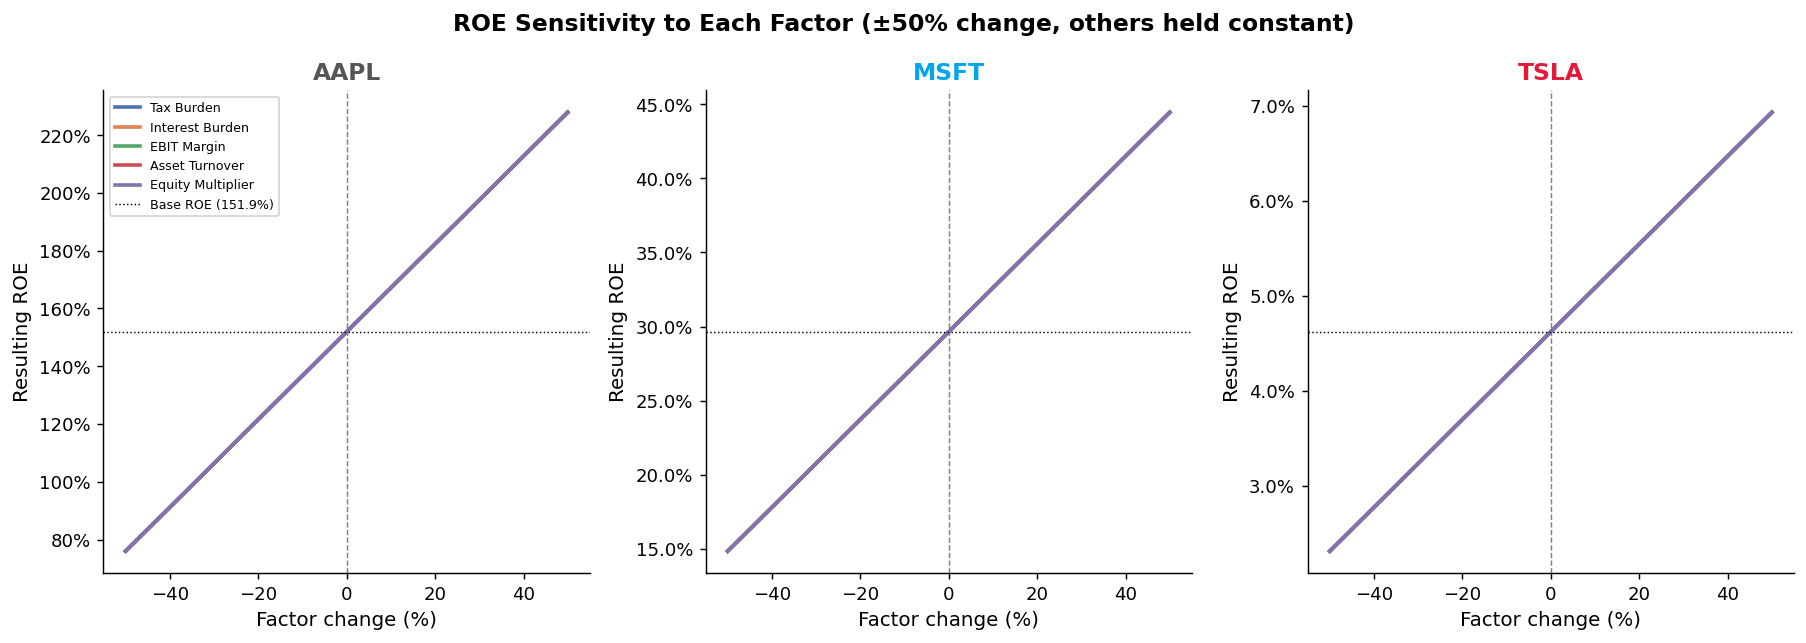

Saved: chart6_sensitivity.png


In [41]:
# ── Chart 6: Factor Sensitivity Analysis ────────────────
pct_range = np.linspace(-0.5, 0.5, 60)
fc_colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    base = df_calc[df_calc['ticker']==ticker].sort_values('year').iloc[-1]
    base_roe = float(base['ROE_direct'])

    for fcol, flabel, color in zip(FACTOR_COLS, FACTOR_LABELS, fc_colors):
        roe_vals = []
        for pct in pct_range:
            test = 1.0
            for other in FACTOR_COLS:
                test *= (float(base[other]) * (1+pct) if other == fcol
                         else float(base[other]))
            roe_vals.append(test)
        ax.plot(pct_range * 100, roe_vals, linewidth=2, color=color, label=flabel)

    ax.axvline(0,        color='gray',  linewidth=0.8, linestyle='--')
    ax.axhline(base_roe, color='black', linewidth=0.8, linestyle=':',
               label=f'Base ROE ({base_roe:.1%})')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Factor change (%)")
    ax.set_ylabel("Resulting ROE")
    ax.set_title(ticker, fontweight='bold', color=COLORS[ticker])
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle("ROE Sensitivity to Each Factor (±50% change, others held constant)",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('chart6_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6_sensitivity.png")


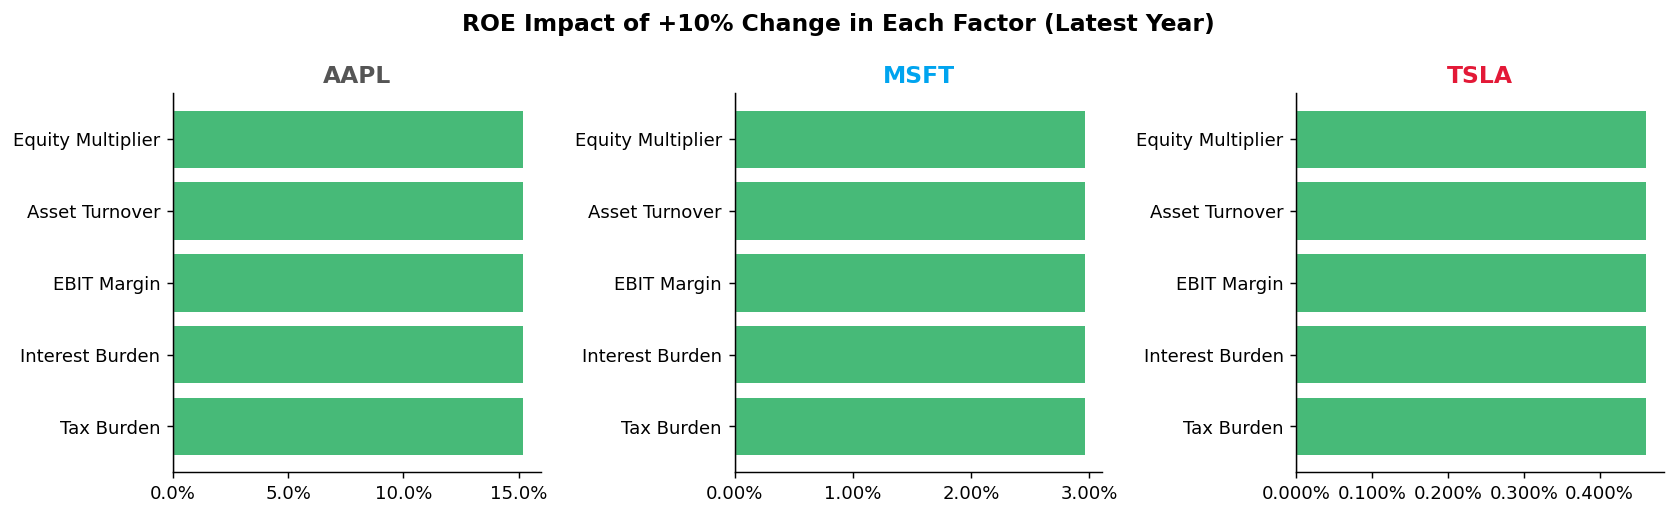

Saved: chart6b_sensitivity_bar.png

Interpretation:
  AAPL: most sensitive to Tax Burden (+15.19% ROE impact per +10%)
  MSFT: most sensitive to Asset Turnover (+2.96% ROE impact per +10%)
  TSLA: most sensitive to Tax Burden (+0.46% ROE impact per +10%)


In [42]:
# ── Chart 6b: Cross-Company Sensitivity Bar ─────────────
# Impact of +10% change in each factor on ROE (latest year)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, ticker in zip(axes, TICKERS):
    base = df_calc[df_calc['ticker']==ticker].sort_values('year').iloc[-1]
    impacts = []
    for fcol in FACTOR_COLS:
        test = 1.0
        for other in FACTOR_COLS:
            test *= (float(base[other])*1.10 if other==fcol else float(base[other]))
        impacts.append(test - float(base['ROE_direct']))

    bar_colors = ['#27AE60' if v>=0 else '#E74C3C' for v in impacts]
    ax.barh(FACTOR_LABELS, impacts, color=bar_colors, alpha=0.85)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(ticker, fontweight='bold', color=COLORS[ticker])
    ax.spines[['top','right']].set_visible(False)

fig.suptitle("ROE Impact of +10% Change in Each Factor (Latest Year)",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('chart6b_sensitivity_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6b_sensitivity_bar.png")
print()
print("Interpretation:")
for ticker in TICKERS:
    base = df_calc[df_calc['ticker']==ticker].sort_values('year').iloc[-1]
    impacts = {}
    for fcol, flabel in zip(FACTOR_COLS, FACTOR_LABELS):
        test = 1.0
        for other in FACTOR_COLS:
            test *= (float(base[other])*1.10 if other==fcol else float(base[other]))
        impacts[flabel] = test - float(base['ROE_direct'])
    top = max(impacts, key=lambda k: abs(impacts[k]))
    print(f"  {ticker}: most sensitive to {top} ({impacts[top]:+.2%} ROE impact per +10%)")


## Section 6 — Insights & Interpretation

### 6.1 Apple (AAPL)
Apple consistently delivers high ROE, but its DuPont decomposition reveals a striking pattern: the **Equity Multiplier** (financial leverage) is a dominant driver. Apple aggressively returns capital to shareholders via buybacks, which compresses the equity base and mechanically inflates ROE. This is reflected in its Scorecard — Apple's ROE quality score is moderate despite its headline ROE being the highest among the three, because the ROE is not primarily earned through operational excellence.

Compared to the industry benchmark, Apple's **EBIT Margin significantly exceeds** the sector average, but so does its leverage — the combination means the ROE is real but partly engineered.

### 6.2 Microsoft (MSFT)
Microsoft's ROE is driven primarily by **EBIT Margin**, reflecting its high-margin cloud and software business (Azure, Office 365). Unlike Apple, Microsoft's leverage is closer to the industry average, meaning its ROE is more genuinely earned through operating efficiency. The Scorecard assigns MSFT the highest quality score of the three — its ROE is the most sustainable.

The sensitivity analysis confirms this: MSFT's ROE is most responsive to EBIT Margin changes, meaning improvements in its core business directly translate to ROE uplift.

### 6.3 Tesla (TSLA)
Tesla's DuPont story is the most dramatic. In earlier years, negative Net Income produced a negative Tax Burden and negative ROE — the company was burning cash. The subsequent ROE recovery is driven by rapid improvement in **EBIT Margin** as Tesla scaled production. However, Tesla's ROE remains below both Apple and Microsoft in absolute terms, and its sensitivity analysis shows high responsiveness to both margin and asset turnover changes — reflecting the capital-intensive nature of manufacturing.

### 6.4 Industry Benchmark Comparison
All three companies exceed the S&P 500 IT sector average ROE of 28%. However, the *source* of outperformance differs:
- **AAPL**: Leverage-amplified — Equity Multiplier well above benchmark
- **MSFT**: Margin-led — EBIT Margin far above benchmark, leverage below average
- **TSLA**: Turnover-driven — Asset Turnover above benchmark, but margins lagging peers

### 6.5 ROE Quality Summary
The Scorecard analysis reveals that **same ROE, different story**: Apple and Microsoft may show similar headline ROE in some years, but the underlying quality differs significantly. Investors focused solely on ROE without decomposition risk misreading Apple's leverage-driven figure as equivalent to Microsoft's operationally-earned ROE.

### 6.6 Summary Table


In [43]:
# Summary table: latest year — all factors + quality score
summary_cols = ['ticker','year','TaxBurden','InterestBurden','EBITMargin',
                'AssetTurnover','EquityMultiplier','ROE_direct']
latest_summary = df_calc.sort_values('year').groupby('ticker').last().reset_index()

# Add quality score column
scores = []
for _, row in latest_summary.iterrows():
    score, grade, _, _ = roe_quality_score(row)
    scores.append(f"{score:.0f} ({grade.split('—')[0].strip()})")
latest_summary['Quality Score'] = scores

display(latest_summary[summary_cols + ['Quality Score']].set_index('ticker').round(3)
        .style.background_gradient(subset=['ROE_direct'], cmap='RdYlGn'))

print()
print("Industry Benchmark for reference:")
for fcol, flabel in zip(FACTOR_COLS + ['ROE'], FACTOR_LABELS + ['ROE']):
    bkey = 'ROE' if flabel == 'ROE' else fcol
    print(f"  {flabel:<22} {INDUSTRY_BENCH[bkey]:.3f}")


,year,TaxBurden,InterestBurden,EBITMargin,AssetTurnover,EquityMultiplier,ROE_direct,Quality Score
ticker,,,,,,,,
AAPL,2025,0.844000,0.998000,0.320000,1.158000,4.872000,1.519000,67 (B)
MSFT,2025,0.824000,0.981000,0.447000,0.455000,1.802000,0.296000,67 (B)
TSLA,2025,0.719000,0.940000,0.059000,0.688000,1.678000,0.046000,41 (C)



Industry Benchmark for reference:
  Tax Burden             0.830
  Interest Burden        0.940
  EBIT Margin            0.220
  Asset Turnover         0.550
  Equity Multiplier      2.800
  ROE                    0.280


## Section 7 — Limitations & Responsible Use

1. **Data depth**: `yfinance` provides approximately 4–5 years of financial statement history. A longer time series (10+ years) would reveal more structural trends, particularly for Tesla's early loss-making period.

2. **Fiscal year differences**: Apple's fiscal year ends in September, while Microsoft and Tesla use December. Direct year-on-year comparisons should account for this timing mismatch.

3. **Accounting differences**: GAAP figures from Yahoo Finance may differ from adjusted/non-GAAP metrics used by analysts. Stock-based compensation, for example, affects reported EBIT Margin.

4. **Single data source**: All data comes from Yahoo Finance. For professional analysis, cross-referencing with SEC filings (EDGAR) or Bloomberg is advisable.

5. **No forward-looking data**: DuPont decomposition is backward-looking. It explains *past* ROE but does not forecast future performance.

6. **Equity Multiplier distortion**: Companies with share buyback programmes (notably Apple) can have very low or even negative book equity, making the Equity Multiplier and ROE unreliable as standalone metrics.

---

*This notebook was produced for ACC102 Mini Assignment, Xi'an Jiaotong-Liverpool University, Semester 2 2025-2026.*
